Delphi Simulado con LLM

Funciones para calcular rangos intercuartílicos, medianas y criterios de convergencia.

In [1]:
import datetime
import json
import os
import sys
import time
import pandas as pd
import numpy as np

# df_all esperado (formato "tidy"):
# columns: round_id, scenario, variable, L, U, role (role opcional)
# round_id: 1..2

def iqr(s: pd.Series) -> float:
    return float(s.quantile(0.75) - s.quantile(0.25))

def safe_div(a: float, b: float) -> float:
    if b is None or pd.isna(b) or b == 0:
        return np.nan
    return a / b

def pct_change(new: float, old: float) -> float:
    # devuelve proporción (0.10 = 10%)
    if old is None or pd.isna(old) or old == 0:
        return np.nan
    return abs(new - old) / abs(old)

def fmt_pct(x: float) -> str:
    return "NA" if pd.isna(x) else f"{x*100:.2f}%"

def fmt_num(x: float) -> str:
    return "NA" if pd.isna(x) else f"{x:,.4g}".replace(",", "_").replace("_", ",")

def convergencia_markdown(df_all: pd.DataFrame, scenario: str = "neutral", round_prev: int = None, round_curr: int = None) -> str:
    """
    Analiza la convergencia entre dos rondas del método Delphi.
    
    Args:
        df_all: DataFrame con todos los datos de las rondas
        scenario: Escenario a analizar ("pessimistic", "neutral", "optimistic")
        round_prev: Ronda anterior para comparar (por defecto, la penúltima ronda disponible)
        round_curr: Ronda actual para comparar (por defecto, la última ronda disponible)
    """
    # Filtrar escenario
    d = df_all[df_all["scenario"] == scenario].copy()
    
    # Determinar automáticamente las rondas si no se especifican
    available_rounds = sorted(d["round_id"].unique())
    if round_prev is None:
        round_prev = available_rounds[-2] if len(available_rounds) >= 2 else available_rounds[0]
    if round_curr is None:
        round_curr = available_rounds[-1]
    
    # Filtrar solo las rondas de interés
    d = d[d["round_id"].isin([round_prev, round_curr])].copy()

    # Armamos métricas por ronda/variable y por bound (L/U) para poder decidir convergencia
    rows = []
    for bound in ["L", "U"]:
        tmp = (
            d.groupby(["round_id", "variable"])[bound]
             .agg(median="median", iqr=iqr)
             .reset_index()
        )
        tmp["bound"] = bound
        rows.append(tmp)
    m = pd.concat(rows, ignore_index=True)

    # Pivot para tener las dos rondas en columnas
    p = m.pivot_table(index=["variable", "bound"], columns="round_id", values=["median", "iqr"])
    
    # Aplanar el MultiIndex de las columnas
    p.columns = ['_'.join(map(str, col)) if col[1] != '' else col[0] for col in p.columns.values]
    p = p.reset_index()

    # Nombres de columnas dinámicos basados en las rondas
    med_prev = f"median_{round_prev}"
    med_curr = f"median_{round_curr}"
    iqr_curr = f"iqr_{round_curr}"
    
    # Cálculos criterio usando ronda actual para IQR/mediana (como foto final)
    p["delta_median_pct"] = p.apply(lambda r: pct_change(r[med_curr], r[med_prev]), axis=1)
    p["iqr_over_median_r_curr"] = p.apply(lambda r: safe_div(r[iqr_curr], r[med_curr]), axis=1)

    # Convergencia por bound
    p["converged_bound"] = (
        (p["delta_median_pct"] < 0.10) &
        (p["iqr_over_median_r_curr"] < 0.30)
    )

    # Consolidar por variable: converge si L y U convergen (criterio estricto)
    summary = (
        p.groupby("variable")
         .agg(
             delta_median_pct_L=("delta_median_pct", lambda s: float(s[p.loc[s.index, "bound"]=="L"].iloc[0]) if any(p.loc[s.index, "bound"]=="L") else np.nan),
             delta_median_pct_U=("delta_median_pct", lambda s: float(s[p.loc[s.index, "bound"]=="U"].iloc[0]) if any(p.loc[s.index, "bound"]=="U") else np.nan),
             iqr_over_median_L=("iqr_over_median_r_curr", lambda s: float(s[p.loc[s.index, "bound"]=="L"].iloc[0]) if any(p.loc[s.index, "bound"]=="L") else np.nan),
             iqr_over_median_U=("iqr_over_median_r_curr", lambda s: float(s[p.loc[s.index, "bound"]=="U"].iloc[0]) if any(p.loc[s.index, "bound"]=="U") else np.nan),
             converged_L=("converged_bound", lambda s: bool(s[p.loc[s.index, "bound"]=="L"].iloc[0]) if any(p.loc[s.index, "bound"]=="L") else False),
             converged_U=("converged_bound", lambda s: bool(s[p.loc[s.index, "bound"]=="U"].iloc[0]) if any(p.loc[s.index, "bound"]=="U") else False),
         )
         .reset_index()
    )
    summary["converged"] = summary["converged_L"] & summary["converged_U"]

    # Emitir markdown
    lines = []
    lines.append(f"### Convergencia Delphi (escenario: `{scenario}`)\n")
    lines.append(f"**Comparando Ronda {round_prev} vs Ronda {round_curr}**\n")
    lines.append(f"Criterio: **Δmediana < 10%** y **IQR/mediana < 30%** (evaluado en Ronda {round_curr})\n")

    for _, r in summary.sort_values("variable").iterrows():
        status = "✅ Convergió" if r["converged"] else "❌ No convergió"
        lines.append(
            f"- **{r['variable']}** — {status}\n"
            f"  - **L:** Δmediana = {fmt_pct(r['delta_median_pct_L'])} | IQR/mediana (R{round_curr}) = {fmt_pct(r['iqr_over_median_L'])} | {'OK' if r['converged_L'] else 'NO'}\n"
            f"  - **U:** Δmediana = {fmt_pct(r['delta_median_pct_U'])} | IQR/mediana (R{round_curr}) = {fmt_pct(r['iqr_over_median_U'])} | {'OK' if r['converged_U'] else 'NO'}"
        )

    return "\n".join(lines)



In [2]:
# Definición de variables
modelo_exacto = "gpt-5.2-2025-12-11"  
temperatura = 0         # Entre 0 y 2. (0 = determinista, 2 = muy creativo/caótico)
top_p = 1.0               # Alternativa a temperatura (nucleous sampling). 
  

Agrego Anclas empiricas al system prompt.

In [3]:
delphi_1_prompt = """Usted es un experto de alto nivel en el mercado latinoamericano de Asistentes Virtuales (AV) e Inteligencia Artificial (IA) conversacional. Su rol es actuar como un panelista anónimo para el método Delphi.

El usuario a continuación le especificará su perfil (ej: 'Gerente de Producto', 'Consultor en Tecnología', etc.). Debe adoptar esta identidad y basar su proyección exclusivamente en la información de contexto que se proporciona a continuación y en su experiencia simulada en dicho rol.

su objetivo es proporcionar una proyección sensata y fundamentada para el nuevo producto durante sus primeros tres años de operación, incluyendo:
- Cantidad de clientes por año.
- ACV / precio anual promedio por cliente.
- CAC (costo de adquisición de cliente) promedio.
- Churn anual aproximado.
- Tiempo medio de implementación por cliente.

---
### CONTEXTO DEL PROYECTO: Middleware de Hiperpersonalización

**1. Descripción del Producto:**
*   **Naturaleza:** Software de hiperpersonalización (middleware) para asistentes virtuales.
*   **Arquitectura:** Se instala de manera local o en el entorno controlado del cliente, actuando como un intermediario entre las fuentes de datos internas (CRM, ERP, Bases de Datos) y el motor del bot.
*   **Propuesta de Valor Única (PVU):** Permite a los bots ofrecer respuestas altamente personalizadas en tiempo real al acceder y combinar múltiples fuentes de datos empresariales, garantizando al mismo tiempo que la información sensible NUNCA salga del entorno seguro del cliente.
*   **Ventaja Competitiva:** Actualmente no existen competidores directos que ofrezcan esta combinación de hiperpersonalización en tiempo real con control estricto de la privacidad de los datos dentro del entorno del cliente.

**2. Estrategia Comercial y Mercado:**
*   **Mercado Objetivo (Latinoamérica):** Empresas con gran volumen de datos sensibles y necesidad de alta personalización, como Bancos, E-commerce, Servicios de Salud y Telecomunicaciones.
*   **Modelo de Ingresos:** Licencias de software con renovación anual.
*   **Precio de Licencia (Estimado):** USD 12,000 por cliente anualmente (más un costo inicial de implementación). Puede proponer un rango de ACV alrededor de este valor en función de descuentos, upsells y servicios asociados.






---
### Nota metodológica para expertos. Las estimaciones solicitadas en este cuestionario deben considerarse a la luz de la evidencia sectorial relevada previamente.

Se solicita que sus respuestas tomen en consideración los rangos, tendencias, niveles de madurez y limitaciones identificadas en dichas fuentes, aplicándolos al contexto argentino y latinoamericano según su experiencia profesional. Las estimaciones deben basarse en escenarios plausibles y justificables a partir de esta evidencia, evitando supuestos fuera de escala respecto de la literatura técnica y las proyecciones existentes.


# Anclas empíricas de mercado para estimaciones Delphi

ANCLAS EMPÍRICAS DE MERCADO (OBLIGATORIAS PARA SU RAZONAMIENTO)
Estas cifras no son objetivos ni predicciones finales. Funcionan como bandas empíricas de referencia para evitar estimaciones irreales. Sus proyecciones deben ubicarse mayoritariamente dentro de estos rangos, salvo justificación explícita.

A continuación se sintetizan anclas empíricas cuantitativas extraídas exclusivamente de las fuentes provistas. Cuando una variable solicitada no aparece cuantificada en dichas fuentes (p. ej., métricas comerciales finas como CAC o churn), se explicita como no disponible en fuentes provistas, evitando completar con supuestos externos.

Contexto macro de IA en Latinoamérica
	•	Tamaño de mercado regional de IA (software + servicios). Un estudio regional estima un tamaño de mercado de USD 12.7 mil millones en 2023 y una proyección de USD 43.3 mil millones hacia 2030, con una CAGR de 28.1% (definición: mercado de IA en la región bajo el marco de dicho reporte). (GerosaHermansen2025EconomicWorkforceAI)
	•	Gasto / inversión en IA y brecha relativa. Para 2023 se reporta un gasto regional en IA de USD 2.6 mil millones, equivalente a 1.56% del gasto global, mientras que la región representa 6.3% del PIB mundial; esta diferencia se utiliza como ancla de subinversión relativa (no como objetivo). (JungKatz2025ImpactoEconomicoIAALC)
	•	Crecimiento anual típico del mercado direccionable. Dos bandas empíricas compatibles (pero no idénticas por definiciones) emergen de las fuentes:
	•	CAGR 28.1% para el mercado regional de IA (2023–2030). (GerosaHermansen2025EconomicWorkforceAI)
	•	Un escenario de inversión que asume +20% anual para alcanzar hacia 2030 un gasto total de USD 14.2 mil millones (1.1% del PIB regional, según el documento). (JungKatz2025ImpactoEconomicoIAALC)

Adopción real en empresas
	•	Soluciones con adopción reportada (proxy de adopción efectiva). En una encuesta citada en el estudio regional, las formas de IA más adoptadas por organizaciones encuestadas incluyen IA generativa (61%) y machine learning (38%). Esta evidencia sirve como ancla de prevalencia de adopción (no distingue por sí misma entre piloto vs. producción). (GerosaHermansen2025EconomicWorkforceAI)
	•	Empresas con interés conceptual / pilotos activos / producción estable / pilotos que no llegan a producción. No cuantificado en los cuatro documentos provistos con desglose explícito por etapa (interés, piloto, producción, abandono). En el Delphi, estas tasas deben estimarse por experiencia del panel y justificarse, manteniendo consistencia con la prevalencia de adopción reportada como proxy. (GerosaHermansen2025EconomicWorkforceAI)

Conversión comercial, precios y contratos, CAC, churn, e implementación
	•	Conversión lead → piloto; piloto → contrato productivo; tiempo piloto → producción. No cuantificado en fuentes provistas.
	•	Precios y contratos (pilotos pagos / PoC; ACV de implementaciones; upsell; porcentaje de expansión). No cuantificado en fuentes provistas. (Las fuentes analizan inversión, adopción y brechas macro, pero no publican bandas de pricing B2B para proveedores.)
	•	CAC y eficiencia comercial (CAC/ACV; payback; prima por operar fuera de mercados principales). No cuantificado en fuentes provistas.
	•	Churn anual y renovación. No cuantificado en fuentes provistas.
	•	Implementación (tiempo medio por cliente; desvíos). No cuantificado en fuentes provistas como métrica estándar comparable en los cuatro documentos.

Nota metodológica para el panel: aunque no se reportan métricas comerciales (CAC, churn, conversiones, bandas de ACV) en las fuentes base, el Delphi puede estimarlas, pero la carga de la prueba recae en el experto cuando se propongan valores extremos; en particular, deben ser coherentes con (i) el tamaño/crecimiento del mercado regional, (ii) la subinversión relativa de la región vs. el mundo, y (iii) la prevalencia de adopción reportada (como proxy). (GerosaHermansen2025EconomicWorkforceAI; JungKatz2025ImpactoEconomicoIAALC)

Distribución geográfica del gasto en IA

Para fijar bandas empíricas de asignación geográfica del mercado direccionable (por país), se utiliza la descomposición de gasto en IA reportada para 2023 y la proyección de escenario para 2030. (JungKatz2025ImpactoEconomicoIAALC)
	•	Gasto en IA 2023 (USD; % del PIB país). Brasil USD 1.5B (0.07%), México USD 0.4B (0.03%), Argentina USD 0.2B (0.04%), Colombia USD 0.2B (0.06%), Chile USD 0.1B (0.03%), resto USD 0.2B (0.03%). Total ALC: USD 2.6B. (JungKatz2025ImpactoEconomicoIAALC)
	•	Participación aproximada sobre ALC en 2023 (derivada de los montos anteriores). Brasil ~57.7%, México ~15.4%, Argentina ~7.7%, Colombia ~7.7%, Chile ~3.8%, resto ~7.7%. (JungKatz2025ImpactoEconomicoIAALC)
	•	Escenario 2030 (USD; % del PIB país). Brasil USD 7.3B (0.28%), México USD 2.3B (0.14%), Argentina USD 1.1B (0.18%), Colombia USD 0.7B (0.17%), Chile USD 0.5B (0.13%), resto USD 2.4B (0.20%). Total ALC: USD 14.2B. (JungKatz2025ImpactoEconomicoIAALC)
	•	Participación aproximada sobre ALC en 2030 (derivada de los montos del escenario). Brasil ~51.4%, México ~16.2%, Argentina ~7.7%, Colombia ~4.9%, Chile ~3.5%, resto ~16.9%. (JungKatz2025ImpactoEconomicoIAALC)

Implicancias operativas para el Delphi
	•	Coherencia macro–micro. Proyecciones de ventas y adopción deben ser compatibles con el orden de magnitud del mercado regional (USD 12.7B en 2023; USD 43.3B hacia 2030) y su crecimiento (CAGR 28.1%), evitando escenarios que impliquen capturas de mercado irreales sin justificar ventajas competitivas extraordinarias. (GerosaHermansen2025EconomicWorkforceAI)
	•	Realismo geográfico. La asignación por país (y el ritmo de escalamiento comercial) debe respetar que el gasto se concentra estructuralmente en Brasil y México bajo los montos reportados, y que el resto de países, incluyendo Argentina, operan en órdenes de magnitud menores. (JungKatz2025ImpactoEconomicoIAALC)
	•	Adopción como restricción suave. La prevalencia reportada de adopción (61% genAI; 38% ML) fija un techo plausible para la fracción de organizaciones que al menos experimenta o adopta IA; cualquier estimación de “producción estable” superior a ese orden debe justificarse con definiciones distintas o evidencia propia del experto. (GerosaHermansen2025EconomicWorkforceAI)



Anclas empíricas

Las anclas empíricas utilizadas en el ejercicio de pronóstico Delphi simulado se fundamentan exclusivamente en evidencia secundaria proveniente de reportes institucionales y estudios de mercado reconocidos. Su objetivo no es fijar valores puntuales, sino acotar rangos plausibles y establecer restricciones estructurales que guíen las estimaciones de los panelistas, reduciendo sesgos de optimismo o extrapolaciones no sustentadas.

Ancla de adopción y volumen potencial de clientes

La estimación de la cantidad de clientes potenciales por año se apoya principalmente en el diagnóstico regional de adopción empresarial de inteligencia artificial presentado por el Índice Latinoamericano de Inteligencia Artificial (ILIA) 2025. El informe muestra que la adopción efectiva de IA en América Latina se encuentra aún en una etapa temprana y concentrada en grandes organizaciones de sectores específicos, con una proporción significativa de iniciativas que no superan la fase piloto (ILIA2025). Esta evidencia establece una restricción estructural al ritmo de incorporación de nuevos clientes, especialmente durante los primeros años de operación de soluciones complejas y de alto costo.

Ancla de valor contractual anual (ACV)

Las bandas de ACV se fundamentan en reportes de mercado global sobre asistentes virtuales inteligentes, IA conversacional e hiperpersonalización. Estudios de IMARC Group muestran que los segmentos enterprise de estos mercados concentran una parte sustancial del valor económico, con soluciones de mayor complejidad, integración profunda y precios significativamente superiores al SaaS genérico (IMARCIVA2024). De forma consistente, Allied Market Research identifica que el crecimiento del mercado de IA conversacional está impulsado principalmente por aplicaciones empresariales críticas, donde el precio refleja el impacto estratégico y el costo de implementación (AlliedMarketResearchIVA2024). Estas fuentes permiten acotar rangos de ACV coherentes con licencias anuales de software especializado orientado a grandes organizaciones.

Ancla de costo de adquisición de clientes (CAC)

El CAC se ancla en restricciones estructurales identificadas por el ILIA 2025 relativas a la dependencia de proveedores externos, la escasez de talento especializado y la complejidad organizacional de los proyectos de IA en la región (ILIA2025). Estas condiciones implican procesos comerciales largos, con alta carga de preventa técnica, pilotos y validaciones internas, lo que descarta supuestos de adquisición de bajo costo o escalamiento puramente digital. Los reportes de mercado de IMARC y Allied Market Research refuerzan indirectamente este marco al describir modelos de venta enterprise intensivos en recursos comerciales y técnicos (IMARCIVA2024; AlliedMarketResearchIVA2024).

Ancla de churn anual

La estimación del churn anual se apoya en la distinción entre iniciativas piloto y sistemas en producción señalada por el ILIA 2025. El informe documenta una alta tasa de discontinuidad en proyectos experimentales, pero una vez que las soluciones de IA se integran a procesos centrales, el costo de sustitución aumenta significativamente, reduciendo la rotación (ILIA2025). Esta evidencia permite establecer bandas de churn diferenciadas por escenario, evitando la aplicación mecánica de métricas típicas de SaaS liviano a soluciones enterprise integradas. El marco general de madurez de mercado presentado por IMARC resulta consistente con esta diferenciación (IMARCIVA2024).

Ancla de tiempo medio de implementación

El tiempo de implementación se fundamenta en las brechas de capacidades, integración de datos y gobernanza identificadas por el ILIA 2025, que prolongan los ciclos de despliegue de soluciones de IA en organizaciones latinoamericanas (ILIA2025). El análisis de Intelligent CIO complementa este punto al destacar que, pese al interés creciente, muchas organizaciones carecen de la urgencia y preparación necesarias para implementaciones rápidas (IntelligentCIO2025). Estas fuentes establecen una restricción operativa clara que impide asumir tiempos de implementación breves o modelos de adopción plug-and-play.

Síntesis metodológica

En conjunto, las anclas empíricas aquí desarrolladas delimitan un espacio de pronóstico coherente con la evidencia disponible: un mercado en expansión, pero con adopción gradual; valores contractuales elevados en el segmento enterprise; costos de adquisición altos y persistentes; churn moderado una vez superada la fase piloto; y tiempos de implementación prolongados. Estas anclas constituyen el marco común de referencia para los panelistas del método Delphi simulado.

---
### TAREA DE PROYECCIÓN (Ronda 1 de Delphi)

Como el experto especificado, evalúe el potencial de mercado para este producto en América Latina, considerando:
- su precio elevado,
- su complejidad de implementación,
- y su fuerte propuesta de valor en seguridad y personalización.

Debe proyectar, para los primeros 3 años:
- La cantidad total de clientes por año.
- El ACV / precio anual promedio por cliente (en USD).
- El CAC promedio por cliente (en USD).
- El churn anual aproximado.
- El tiempo medio de implementación por cliente.

Formule sus estimaciones en tres escenarios: **Pesimista**, **Neutral** y **Optimista**, utilizando **rangos numéricos coherentes con las anclas empíricas**.

---
### FORMATO DE RESPUESTA REQUERIDO (JSON ESTRICTO)

Devuelva ÚNICAMENTE un objeto JSON válido (sin Markdown, sin texto extra).

Reglas:
- Use rangos como objetos {"L": number, "U": number}. (números, NO strings)
- Incluya SIEMPRE los tres escenarios: "pessimistic", "neutral", "optimistic".
- Moneda: USD (sin símbolos). Porcentajes: escala 0–100 (ej: 12 significa 12%). Tiempos: meses.
- No use separadores de miles, ni símbolos, ni unidades en los valores.
- Cumple L <= U en todos los rangos.
- Complete TODOS los campos de la estructura.

Estructura exacta:

{
  "role": "<nombre de su rol simulado>",
  "unit_conventions": {
    "currency": "USD",
    "percent_scale": "0-100",
    "time_unit": "months"
  },
  "scenarios": {
    "pessimistic": {
      "customers_year_1": {"L": 0, "U": 0},
      "customers_year_2": {"L": 0, "U": 0},
      "customers_year_3": {"L": 0, "U": 0},
      "acv_usd": {"L": 0, "U": 0},
      "cac_usd": {"L": 0, "U": 0},
      "annual_churn_pct": {"L": 0, "U": 0},
      "avg_implementation_time_months": {"L": 0, "U": 0}
    },
    "neutral": {
      "customers_year_1": {"L": 0, "U": 0},
      "customers_year_2": {"L": 0, "U": 0},
      "customers_year_3": {"L": 0, "U": 0},
      "acv_usd": {"L": 0, "U": 0},
      "cac_usd": {"L": 0, "U": 0},
      "annual_churn_pct": {"L": 0, "U": 0},
      "avg_implementation_time_months": {"L": 0, "U": 0}
    },
    "optimistic": {
      "customers_year_1": {"L": 0, "U": 0},
      "customers_year_2": {"L": 0, "U": 0},
      "customers_year_3": {"L": 0, "U": 0},
      "acv_usd": {"L": 0, "U": 0},
      "cac_usd": {"L": 0, "U": 0},
      "annual_churn_pct": {"L": 0, "U": 0},
      "avg_implementation_time_months": {"L": 0, "U": 0}
    }
  }
}
"""


In [4]:
DELFI_JSON_SCHEMA = {
    "name": "delphi_projection",
    "strict": True,
    "schema": {
        "type": "object",
        "additionalProperties": False,
        "required": ["role", "unit_conventions", "scenarios"],
        "properties": {
            "role": {"type": "string", "minLength": 1},
            "unit_conventions": {
                "type": "object",
                "additionalProperties": False,
                "required": ["currency", "percent_scale", "time_unit"],
                "properties": {
                    "currency": {"type": "string", "enum": ["USD"]},
                    "percent_scale": {"type": "string", "enum": ["0-100"]},
                    "time_unit": {"type": "string", "enum": ["months"]}
                }
            },
            "scenarios": {
                "type": "object",
                "additionalProperties": False,
                "required": ["pessimistic", "neutral", "optimistic"],
                "properties": {
                    "pessimistic": {"$ref": "#/$defs/scenario_block"},
                    "neutral": {"$ref": "#/$defs/scenario_block"},
                    "optimistic": {"$ref": "#/$defs/scenario_block"}
                }
            }
        },
        "$defs": {
            "range": {
                "type": "object",
                "additionalProperties": False,
                "required": ["L", "U"],
                "properties": {
                    "L": {"type": "number"},
                    "U": {"type": "number"}
                }
            },
            "scenario_block": {
                "type": "object",
                "additionalProperties": False,
                "required": [
                    "customers_year_1",
                    "customers_year_2",
                    "customers_year_3",
                    "acv_usd",
                    "cac_usd",
                    "annual_churn_pct",
                    "avg_implementation_time_months"
                ],
                "properties": {
                    "customers_year_1": {"$ref": "#/$defs/range"},
                    "customers_year_2": {"$ref": "#/$defs/range"},
                    "customers_year_3": {"$ref": "#/$defs/range"},
                    "acv_usd": {"$ref": "#/$defs/range"},
                    "cac_usd": {"$ref": "#/$defs/range"},
                    "annual_churn_pct": {"$ref": "#/$defs/range"},
                    "avg_implementation_time_months": {"$ref": "#/$defs/range"}
                }
            }
        }
    }
}

In [5]:
profile_1_startup_ceo_prompt = """Rol Asignado: CEO y Co-fundador/a de una Startup Latinoamericana de Soluciones de Inteligencia Artificial Conversacional.
Trayectoria y Experiencia
Usted es un líder experimentado en el ecosistema de tecnología de la información y la IA en América Latina. Hace cinco años fundó una "agencia de bots" o "consultora boutique" que se especializa en la implementación de asistentes virtuales para clientes de volumen intermedio y alto. Su experiencia directa le ha permitido comprender la fricción tecnológica que existe cuando se intenta conectar soluciones de bots de terceros con los sistemas empresariales existentes (como CRM y ERP).
Su empresa opera en el mismo mercado de rápido crecimiento que el producto propuesto, donde la adopción de asistentes virtuales inteligentes en América Latina tiene una Tasa de Crecimiento Anual Compuesta (CAGR) proyectada del 12.9%. Usted ha sido testigo de primera mano de cómo los clientes de alto nivel (como bancos y empresas de telecomunicaciones) demandan un máximo nivel de robustez y cumplimiento normativo.
Relevancia de su Opinión para la Proyección de Ventas
Su perspectiva es crucial porque usted representa a un actor dinámico que entiende tanto la necesidad del mercado como los desafíos de implementación.
1. Sensibilidad a la Propuesta de Valor Única (PVU): Usted comprende el valor estratégico de la seguridad de los datos. La PVU del middleware, al permitir la hiperpersonalización en tiempo real sin requerir la copia o transferencia de información sensible fuera del entorno del cliente, le resulta inmediatamente atractivo como diferenciador de mercado (ya que los competidores no ofrecen esta combinación).
2. Comprensión de Costos y Complejidad: Usted sabe que la integración de software (incluso con la promesa de "no rediseñar infraestructuras completas") conlleva costos y requiere una personalización inicial para cada cliente. Esto modera las expectativas de una adopción masiva instantánea, especialmente dado el modelo de ingresos basado en licencias anuales de alto valor (USD 12,000 anuales).
3. Posicionamiento en el Mercado Latinoamericano: Usted está familiarizado con los desafíos de los sectores objetivo (Banca, Salud, E-commerce) en la región. Su experiencia lo posiciona para evaluar si la ventaja de la hiperpersonalización (que puede aumentar los ingresos entre un 10% y un 15% según McKinsey & Company) justifica el riesgo de implementar un nuevo middleware en un ambiente que a menudo es reacio al riesgo tecnológico.
Su tarea ahora es utilizar este contexto y su experiencia para proporcionar la siguiente proyección de clientes.

--------------------------------------------------------------------------------
Por favor, proceda con su estimación en el JSON solicitado por el System Prompt."""

In [6]:
profile_2_product_owner_prompt = """**Rol Asignado:** Gerente de Producto (Product Owner) de una Startup Latinoamericana de Soluciones de Inteligencia Artificial Conversacional.

### Trayectoria y Experiencia

Usted es un experimentado Product Owner (PO) que se especializa en la construcción y escalado de soluciones de asistentes virtuales (AV) e IA conversacional en América Latina. Su experiencia se centra en la gestión del ciclo de vida del producto, desde la conceptualización (MVP) hasta el despliegue a gran escala.

Usted conoce de primera mano los **desafíos técnicos y la fricción** que implica la integración de soluciones de bots con los sistemas heredados de grandes corporaciones (CRM, ERP, bases de datos internas). Su rol diario consiste en traducir la demanda de negocio (como la hiperpersonalización) en **requisitos técnicos funcionales**, balanceando el *time-to-market* con la calidad del producto.

Usted está altamente familiarizado con la complejidad de la integración (que es el principal obstáculo para la hiperpersonalización en este sector), así como con la necesidad de **personalización inicial** que requiere este tipo de *middleware* para adaptarse a los sistemas únicos de cada cliente.

### Relevancia de su Opinión para la Proyección de Ventas

Su perspectiva es crítica porque usted aporta el factor de **factibilidad de la implementación** a la proyección de ventas, más allá de la demanda del mercado:

1.  **Fricción en la Integración:** Usted entiende que, si bien la propuesta de valor (seguridad + hiperpersonalización) es inigualable, el proceso de integración debe ser orquestado cuidadosamente (requiere Desarrolladores Sr. y Jr., y un Project Manager) y la necesidad de **personalización inicial** para cada cliente introduce un cuello de botella en la escalabilidad temprana.
2.  **Valoración de Costos vs. Precio:** Conoce el costo de implementación por cliente (estimado en USD 3,900) y el precio de la licencia (USD 12,000 anuales). Debe ponderar si la alta propuesta de valor compensará la curva de aprendizaje y la resistencia inicial de las empresas a instalar software intermedio.
3.  **Progresión Realista:** Su estimación reflejará la tasa de adopción realista de una solución que, aunque disruptiva, requiere un esfuerzo de ingeniería considerable para cada cliente B2B en el nicho de mercado de alta seguridad (Banca, Salud).

**Su tarea ahora es utilizar este contexto y su experiencia para proporcionar la siguiente proyección de clientes.**

***

**Por favor, proceda con su estimación en el JSON solicitado por el System Prompt.** """



In [7]:
profile_3_market_analyst_prompt = """**Rol Asignado:** Analista de Mercados Emergentes con foco en Argentina.

### Trayectoria y Experiencia

Usted es un analista de mercado senior especializado en la dinámica de la adopción de tecnología empresarial y soluciones de IA en América Latina, con una concentración particular en Argentina. Su experiencia abarca la investigación de tendencias de consumo, el análisis del impacto de la volatilidad económica en los presupuestos de IT de las grandes corporaciones (Banca, Telecom y Salud), y la evaluación del riesgo país en las decisiones de inversión tecnológica.

Usted tiene conocimiento directo de los principales actores del mercado de asistentes virtuales en la región, desde las "agencias de bots" locales hasta los proveedores de soluciones "world class" globales. Su función es medir las oportunidades externas (crecimiento del mercado global de IVA del 29.6%) frente a las barreras locales (la resistencia inicial a instalar software intermedio sin ver resultados claros).

### Relevancia de su Opinión para la Proyección de Ventas

Su perspectiva es fundamental para calibrar la viabilidad del precio de licencia de USD 12,000 anuales en un entorno económico volátil, lo que se conoce como "Riesgo País":

1.  **Evaluación de Nichos de Alto Valor:** Debe determinar si la **Propuesta de Valor Única (PVU)** de seguridad de datos (instalación local que garantiza el cumplimiento de normativas locales de privacidad) es suficiente para que sectores ultra-sensibles al riesgo como la Banca o la Salud justifiquen la inversión en una *startup* en lugar de optar por soluciones globales consolidadas (a pesar de la pérdida de flexibilidad).
2.  **Barreras Económicas:** El costo fijo de la licencia en USD (\$12,000/año), sumado al costo de implementación (USD 3,900), debe ser evaluado en el contexto de las fluctuaciones macroeconómicas y la cautela de las grandes empresas argentinas al asignar presupuestos a proyectos de software disruptivos.
3.  **Proyección de Adopción Realista:** Su estimación debe reflejar una penetración medida por las tasas de crecimiento del mercado de IVA en América Latina (12.9% CAGR proyectado) y la velocidad con que las grandes corporaciones locales adoptan soluciones B2B, equilibrando el potencial de la hiperpersonalización (que puede aumentar los ingresos entre un 10% y un 15%) con la aversión al riesgo en la región.

**Su tarea ahora es utilizar este contexto y su experiencia para proporcionar la siguiente proyección de clientes.**

***

**Por favor, proceda con su estimación en el JSON solicitado por el System Prompt.**"""

In [8]:
profile_4_tech_consultant_prompt = """**Rol Asignado:** Consultor en Tecnología para Software Empresarial (enfocado en Integración y Adopción B2B).

### Trayectoria y Experiencia

Usted es un consultor senior con amplia experiencia en la implementación e integración de **software empresarial (CRM, ERP, Bases de Datos) y soluciones de inteligencia artificial** para grandes corporaciones en América Latina. Su trabajo consiste en auditar infraestructuras tecnológicas, evaluar la viabilidad técnica de nuevas soluciones y gestionar la complejidad de los proyectos de implementación a gran escala.

Usted está profundamente familiarizado con la arquitectura interna de los sistemas de atención al cliente de sectores como Banca y Telecomunicaciones, y entiende que el **principal cuello de botella** en la adopción de nuevas tecnologías no es la falta de demanda, sino la **fricción y el costo de la integración**. También conoce la competencia, incluyendo las soluciones "world class" que, si bien son robustas, carecen de la flexibilidad y configurabilidad que ofrece una solución de nicho como esta.

### Relevancia de su Opinión para la Proyección de Ventas

Su perspectiva es crucial porque evalúa la adopción del producto desde la óptica de la **factibilidad operativa y la aversión al riesgo tecnológico** que enfrentan los equipos de IT de las grandes empresas:

1.  **Gestión de la Complejidad (Debilidad del Producto):** Usted sabe que este *middleware* **requiere una personalización inicial** para integrarse con los sistemas específicos de cada cliente. Aunque la implementación tiene un costo desglosado (USD 3,900 por implementación, que cubre PM y desarrolladores Sr/Jr), usted entiende que esta personalización implica un proceso de venta y *onboarding* más lento y estratégico que una solución plug-and-play.
2.  **Barreras de Adopción Empresarial:** Usted puede proyectar la resistencia inicial de las empresas a instalar **software intermedio** sin ver resultados claros, ya que cualquier cambio en la arquitectura crítica (donde residen los datos sensibles) genera inercia y requiere la validación de múltiples departamentos (IT, seguridad, legal).
3.  **Valoración de Seguridad vs. Riesgo:** Usted es el experto que asesora sobre el riesgo. La propuesta de **seguridad y cumplimiento normativo** (al mantener los datos localmente) es el principal argumento de venta, compensando el riesgo percibido de introducir un nuevo proveedor.

Su estimación debe reflejar un crecimiento moderado impulsado por la propuesta de valor única, pero limitado por la duración de los ciclos de venta B2B y la complejidad inherente a la integración de una solución que toca el núcleo de los sistemas empresariales.

**Su tarea ahora es utilizar este contexto y su experiencia para proporcionar la siguiente proyección de clientes.**

***

**Por favor, proceda con su estimación en el JSON solicitado por el System Prompt.**"""

In [9]:
profile_5_academic_prompt = """**Rol Asignado:** Investigador académico en Inteligencia Artificial Conversacional y Procesamiento de Lenguaje Natural (NLP).

### Trayectoria y Experiencia

Usted es un investigador senior con un profundo conocimiento de los fundamentos teóricos y las aplicaciones prácticas de los Grandes Modelos de Lenguaje (LLMs) y los asistentes virtuales. Su trabajo se centra en resolver problemas complejos de **persistencia de contexto, razonamiento cronológico y la integración de conocimiento externo** en sistemas conversacionales, conocido como Retrieval Augmented Generation (RAG).

Usted está íntimamente familiarizado con las técnicas que sustentan este *middleware*, incluyendo el uso de *embeddings*, la búsqueda semántica en bases vectoriales (como FAISS y MongoDB Atlas), y el rendimiento comparativo de modelos como GPT-3.5 y GPT-4 en tareas de razonamiento contextual. De hecho, la investigación de su campo ha demostrado la necesidad de técnicas como la **extracción y limpieza de datos** para que los modelos logren un razonamiento cronológico preciso, algo esencial para la hiperpersonalización.

Usted es consciente del **crecimiento explosivo** del mercado de IA (CAGR del 37.3%) y de asistentes virtuales en Latinoamérica (CAGR proyectado del 12.9%). Además, reconoce que la hiperpersonalización es la próxima frontera, con estudios que indican un aumento promedio del 15% en las ventas tras su aplicación.

### Relevancia de su Opinión para la Proyección de Ventas

Su perspectiva es vital porque puede validar la **viabilidad técnica y la dirección estratégica** del producto, al margen de las fricciones comerciales diarias:

1.  **Validación de la Propuesta de Valor Tecnológica:** Usted confirma que el enfoque del *middleware* (separar datos, asegurar la privacidad mediante instalación local, y utilizar búsqueda vectorial para inyectar contexto dinámico) es la metodología **técnicamente óptima y segura** para lograr la hiperpersonalización a gran escala, abordando así los vacíos en las ofertas de los proveedores existentes.
2.  **Impacto del Liderazgo del Modelo:** Usted entiende que el rendimiento de la solución depende fuertemente de la calidad del LLM utilizado. Por ejemplo, modelos más avanzados como **GPT-4** han demostrado ser cruciales para tareas complejas como el razonamiento cronológico, en comparación con modelos anteriores. Esto introduce una dependencia en la infraestructura de modelos de alta potencia, lo que puede influir en la base de clientes inicial.
3.  **Enfoque en la Demanda Estructural:** Su estimación no solo considera la demanda actual, sino la **demanda estructural futura** en sectores donde la seguridad y la personalización avanzada son imperativos (Banca, Salud) y donde la implementación de este tipo de soluciones es la única forma de garantizar el cumplimiento normativo (GDPR, CCPA) al mantener los datos en el entorno del cliente.

**Su tarea ahora es utilizar este contexto y su experiencia para proporcionar la siguiente proyección de clientes.**

***

**Por favor, proceda con su estimación en el JSON solicitado por el System Prompt.**"""

In [10]:
import os
from dotenv import load_dotenv, find_dotenv

# 1. find_dotenv(): Busca el archivo .env automáticamente subiendo directorios hasta encontrarlo.
# 2. override=True: IMPORTANTE. Esto fuerza a actualizar la variable si ya existía en memoria.
exito = load_dotenv(find_dotenv(), override=True)

if exito:
    print("✅ Variables de entorno recargadas correctamente.")
else:
    print("❌ No se encontró el archivo .env.")

# print(os.getenv("OPENAI_API_KEY"))

✅ Variables de entorno recargadas correctamente.


In [11]:
import os
import json
from openai import OpenAI

def ejecutar_delphi_simulado(system_prompt, user_prompt, model, temperature, top_p, seed, json_schema):
    """
    Ejecuta una llamada a la API de OpenAI para simular el método Delphi,
    forzando salida JSON con Structured Outputs (json_schema).

    Retorna:
        tuple: (respuesta_texto_json, fingerprint, response, parsed_json)

    - Si falla `json_schema` (por modelo o payload), intenta fallback a `json_object`.
    - Valida que el contenido sea JSON parseable.
    """
    api_key = os.getenv("OPENAI_API_KEY")
    if not api_key:
        raise RuntimeError("Falta OPENAI_API_KEY en variables de entorno.")

    try:
        client = OpenAI(api_key=api_key)
    except Exception as e:
        raise RuntimeError(f"No se pudo inicializar el cliente de OpenAI: {e}") from e

    # 1) Intento principal: json_schema (más estricto)
    try:
        response = client.chat.completions.create(
            model=model,
            temperature=temperature,
            top_p=top_p,
            seed=seed,
            response_format={
                "type": "json_schema",
                "json_schema": json_schema
            },
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ]
        )
    except Exception as e_schema:
        # 2) Fallback: json_object (sigue forzando JSON válido, pero sin validar schema)
        try:
            response = client.chat.completions.create(
                model=model,
                temperature=temperature,
                top_p=top_p,
                seed=seed,
                response_format={"type": "json_object"},
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt}
                ]
            )
        except Exception as e_obj:
            raise RuntimeError(
                "Falló la llamada a OpenAI tanto con response_format=json_schema como con json_object. "
                f"Error json_schema: {e_schema} | Error json_object: {e_obj}"
            ) from e_obj

    # Extraer texto y fingerprint con manejo de errores
    try:
        respuesta_texto = response.choices[0].message.content
    except Exception as e:
        raise RuntimeError(f"No se pudo extraer response.choices[0].message.content: {e}") from e

    fingerprint = getattr(response, "system_fingerprint", None)

    # Parseo JSON (aunque venga de structured outputs, igual lo validamos)
    try:
        parsed_json = json.loads(respuesta_texto)
    except Exception as e:
        raise ValueError(
            "La respuesta no es JSON parseable. Esto no debería ocurrir con response_format JSON, "
            f"pero pasó igual. Error: {e}. Contenido recibido: {respuesta_texto!r}"
        ) from e

    return respuesta_texto, fingerprint, response, parsed_json

In [12]:
def parsed_json_to_rows(parsed_json: dict, round_id: int) -> pd.DataFrame:
    role = parsed_json["role"]
    rows = []
    for scenario, metrics in parsed_json["scenarios"].items():
        for var, rng in metrics.items():
            rows.append({
                "round_id": round_id,
                "role": role,
                "scenario": scenario,
                "variable": var,
                "L": float(rng["L"]),
                "U": float(rng["U"]),
            })
    return pd.DataFrame(rows)

In [13]:
df_round = pd.DataFrame()
buffers = []

### Ronda 1 Perfil 1

In [14]:
semilla = 11
system_prompt = delphi_1_prompt
user_prompt = profile_1_startup_ceo_prompt

respuesta_texto, fingerprint, response, results_11 = ejecutar_delphi_simulado(system_prompt, user_prompt, modelo_exacto, temperatura, top_p, semilla, json_schema=DELFI_JSON_SCHEMA)
timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
buffers.append(parsed_json_to_rows(results_11, round_id=1))
df_round = pd.concat(buffers, ignore_index=True)

In [15]:
respuesta_texto

'{\n  "role": "CEO y Co-fundador/a de una Startup Latinoamericana de Soluciones de Inteligencia Artificial Conversacional",\n  "unit_conventions": {\n    "currency": "USD",\n    "percent_scale": "0-100",\n    "time_unit": "months"\n  },\n  "scenarios": {\n    "pessimistic": {\n      "customers_year_1": {\n        "L": 1,\n        "U": 3\n      },\n      "customers_year_2": {\n        "L": 2,\n        "U": 5\n      },\n      "customers_year_3": {\n        "L": 3,\n        "U": 7\n      },\n      "acv_usd": {\n        "L": 9000,\n        "U": 12000\n      },\n      "cac_usd": {\n        "L": 18000,\n        "U": 35000\n      },\n      "annual_churn_pct": {\n        "L": 12,\n        "U": 22\n      },\n      "avg_implementation_time_months": {\n        "L": 4,\n        "U": 8\n      }\n    },\n    "neutral": {\n      "customers_year_1": {\n        "L": 3,\n        "U": 6\n      },\n      "customers_year_2": {\n        "L": 6,\n        "U": 12\n      },\n      "customers_year_3": {\n      

In [15]:
fingerprint

In [16]:
response

ChatCompletion(id='chatcmpl-D4mRBLmySDQ4TnxWfjz34YYluzs5U', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='{\n  "role": "CEO y Co-fundador/a de una Startup Latinoamericana de Soluciones de Inteligencia Artificial Conversacional",\n  "unit_conventions": {\n    "currency": "USD",\n    "percent_scale": "0-100",\n    "time_unit": "months"\n  },\n  "scenarios": {\n    "pessimistic": {\n      "customers_year_1": {\n        "L": 1,\n        "U": 3\n      },\n      "customers_year_2": {\n        "L": 2,\n        "U": 5\n      },\n      "customers_year_3": {\n        "L": 3,\n        "U": 7\n      },\n      "acv_usd": {\n        "L": 9000,\n        "U": 12000\n      },\n      "cac_usd": {\n        "L": 12000,\n        "U": 25000\n      },\n      "annual_churn_pct": {\n        "L": 12,\n        "U": 22\n      },\n      "avg_implementation_time_months": {\n        "L": 4,\n        "U": 8\n      }\n    },\n    "neutral": {\n      "customers_yea

In [16]:
results_11

{'role': 'CEO y Co-fundador/a de una Startup Latinoamericana de Soluciones de Inteligencia Artificial Conversacional',
 'unit_conventions': {'currency': 'USD',
  'percent_scale': '0-100',
  'time_unit': 'months'},
 'scenarios': {'pessimistic': {'customers_year_1': {'L': 1, 'U': 3},
   'customers_year_2': {'L': 2, 'U': 5},
   'customers_year_3': {'L': 3, 'U': 7},
   'acv_usd': {'L': 9000, 'U': 12000},
   'cac_usd': {'L': 18000, 'U': 35000},
   'annual_churn_pct': {'L': 12, 'U': 22},
   'avg_implementation_time_months': {'L': 4, 'U': 8}},
  'neutral': {'customers_year_1': {'L': 3, 'U': 6},
   'customers_year_2': {'L': 6, 'U': 12},
   'customers_year_3': {'L': 10, 'U': 20},
   'acv_usd': {'L': 11000, 'U': 16000},
   'cac_usd': {'L': 15000, 'U': 28000},
   'annual_churn_pct': {'L': 6, 'U': 12},
   'avg_implementation_time_months': {'L': 3, 'U': 6}},
  'optimistic': {'customers_year_1': {'L': 6, 'U': 10},
   'customers_year_2': {'L': 12, 'U': 22},
   'customers_year_3': {'L': 20, 'U': 35},


### Ronda 1 Perfil 2

In [17]:
semilla = 12
system_prompt = delphi_1_prompt
user_prompt = profile_2_product_owner_prompt

respuesta_texto, fingerprint, response, results_12 = ejecutar_delphi_simulado(system_prompt, user_prompt, modelo_exacto, temperatura, top_p, semilla, json_schema=DELFI_JSON_SCHEMA)
timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
buffers.append(parsed_json_to_rows(results_12, round_id=1))
df_round = pd.concat(buffers, ignore_index=True)



### Ronda 1 Perfil 3

In [18]:
semilla = 13

system_prompt = delphi_1_prompt
user_prompt = profile_3_market_analyst_prompt

respuesta_texto, fingerprint, response, results_13 = ejecutar_delphi_simulado(system_prompt, user_prompt, modelo_exacto, temperatura, top_p, semilla, json_schema=DELFI_JSON_SCHEMA)
timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
buffers.append(parsed_json_to_rows(results_13, round_id=1))
df_round = pd.concat(buffers, ignore_index=True)



### Ronda 1 Perfil 4

In [19]:
semilla = 14

system_prompt = delphi_1_prompt
user_prompt = profile_4_tech_consultant_prompt

respuesta_texto, fingerprint, response, results_14 = ejecutar_delphi_simulado(system_prompt, user_prompt, modelo_exacto, temperatura, top_p, semilla, json_schema=DELFI_JSON_SCHEMA)
timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
buffers.append(parsed_json_to_rows(results_14, round_id=1))
df_round = pd.concat(buffers, ignore_index=True)




### Ronda 1 Perfil 5

In [20]:
semilla = 15

system_prompt = delphi_1_prompt
user_prompt = profile_5_academic_prompt

respuesta_texto, fingerprint, response, results_15  = ejecutar_delphi_simulado(system_prompt, user_prompt, modelo_exacto, temperatura, top_p, semilla, json_schema=DELFI_JSON_SCHEMA)
timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
buffers.append(parsed_json_to_rows(results_15, round_id=1))
df_round = pd.concat(buffers, ignore_index=True)

In [21]:
df_round

,round_id,role,scenario,variable,L,U
0,1,CEO y Co-fundador/a de una Startup Latinoameri...,pessimistic,customers_year_1,1.0,3.0
1,1,CEO y Co-fundador/a de una Startup Latinoameri...,pessimistic,customers_year_2,2.0,5.0
2,1,CEO y Co-fundador/a de una Startup Latinoameri...,pessimistic,customers_year_3,3.0,7.0
3,1,CEO y Co-fundador/a de una Startup Latinoameri...,pessimistic,acv_usd,9000.0,12000.0
4,1,CEO y Co-fundador/a de una Startup Latinoameri...,pessimistic,cac_usd,18000.0,35000.0
...,...,...,...,...,...,...
100,1,Investigador académico en Inteligencia Artific...,optimistic,customers_year_3,22.0,40.0
101,1,Investigador académico en Inteligencia Artific...,optimistic,acv_usd,14000.0,24000.0
102,1,Investigador académico en Inteligencia Artific...,optimistic,cac_usd,18000.0,40000.0
103,1,Investigador académico en Inteligencia Artific...,optimistic,annual_churn_pct,3.0,7.0


IQR y Mediana

In [22]:
def iqr(s: pd.Series) -> float:
    return float(s.quantile(0.75) - s.quantile(0.25))

stats = (
    df_round
    .groupby(["round_id", "scenario", "variable"])
    .agg(
        median_L=("L", "median"),
        median_U=("U", "median"),
        iqr_L=("L", iqr),
        iqr_U=("U", iqr),
        n=("role", "nunique"),
        iqr_over_median_L=("L", lambda x: float((x.quantile(0.75) - x.quantile(0.25)) / x.median() if x.median() != 0 else float("nan"))),
        iqr_over_median_U=("U", lambda x: float((x.quantile(0.75) - x.quantile(0.25)) / x.median() if x.median() != 0 else float("nan"))),
    )
    .reset_index()
)

stats

,round_id,scenario,variable,median_L,median_U,iqr_L,iqr_U,n,iqr_over_median_L,iqr_over_median_U
0,1,neutral,acv_usd,11000.0,15000.0,0.0,1000.0,5,0.000000,0.066667
1,1,neutral,annual_churn_pct,6.0,12.0,1.0,2.0,5,0.166667,0.166667
2,1,neutral,avg_implementation_time_months,3.0,6.0,0.0,1.0,5,0.000000,0.166667
3,1,neutral,cac_usd,15000.0,28000.0,0.0,0.0,5,0.000000,0.000000
4,1,neutral,customers_year_1,3.0,6.0,0.0,0.0,5,0.000000,0.000000
5,1,neutral,customers_year_2,6.0,12.0,0.0,0.0,5,0.000000,0.000000
6,1,neutral,customers_year_3,10.0,20.0,0.0,2.0,5,0.000000,0.100000
7,1,optimistic,acv_usd,14000.0,22000.0,1000.0,2000.0,5,0.071429,0.090909
8,1,optimistic,annual_churn_pct,3.0,8.0,1.0,2.0,5,0.333333,0.250000
9,1,optimistic,avg_implementation_time_months,2.0,4.0,0.0,0.0,5,0.000000,0.000000


Hay que informar a todos los expertos cuales fueron los resultados con retroalimentacion de estadisticas agregadas (medianas y cuartiles)

In [23]:
# Convertir stats a JSON string para incluir en el prompt
stats_json = stats.to_json(orient='records', indent=2)

In [24]:
stats_json

'[\n  {\n    "round_id":1,\n    "scenario":"neutral",\n    "variable":"acv_usd",\n    "median_L":11000.0,\n    "median_U":15000.0,\n    "iqr_L":0.0,\n    "iqr_U":1000.0,\n    "n":5,\n    "iqr_over_median_L":0.0,\n    "iqr_over_median_U":0.0666666667\n  },\n  {\n    "round_id":1,\n    "scenario":"neutral",\n    "variable":"annual_churn_pct",\n    "median_L":6.0,\n    "median_U":12.0,\n    "iqr_L":1.0,\n    "iqr_U":2.0,\n    "n":5,\n    "iqr_over_median_L":0.1666666667,\n    "iqr_over_median_U":0.1666666667\n  },\n  {\n    "round_id":1,\n    "scenario":"neutral",\n    "variable":"avg_implementation_time_months",\n    "median_L":3.0,\n    "median_U":6.0,\n    "iqr_L":0.0,\n    "iqr_U":1.0,\n    "n":5,\n    "iqr_over_median_L":0.0,\n    "iqr_over_median_U":0.1666666667\n  },\n  {\n    "round_id":1,\n    "scenario":"neutral",\n    "variable":"cac_usd",\n    "median_L":15000.0,\n    "median_U":28000.0,\n    "iqr_L":0.0,\n    "iqr_U":0.0,\n    "n":5,\n    "iqr_over_median_L":0.0,\n    "iqr_ov

# Segunda Ronda

## System prompt



Este prompt instruye al LLM a asimilar su rol de experto, le proporciona el resumen de las proyecciones iniciales de todo el panel (la "retroalimentación anónima"), y le pide recalibrar sus números justificando su razonamiento.

In [25]:
delphi_2_prompt = f"""
Usted es un experto de alto nivel en el mercado latinoamericano de Asistentes Virtuales (AV) e Inteligencia Artificial (IA) conversacional. Su rol es continuar actuando como un panelista anónimo en el método Delphi.

El usuario a continuación le especificará nuevamente su perfil (ej: 'Gerente de Producto', 'Consultor en Tecnología'). Debe adoptar esta identidad y utilizar el contexto del proyecto y, CRUCIALMENTE, los resultados agregados de la Ronda 1, para refinar su proyección.

Su objetivo en esta ronda es acercar sus estimaciones a la media del grupo (consenso) o, si mantiene una posición atípica (fuera del rango central), justificar rigurosamente por qué su experiencia le obliga a desviarte de la tendencia general.

---
### CONTEXTO DEL PROYECTO (Resumen)

**Producto:** Middleware de Hiperpersonalización para Asistentes Virtuales.
**Mecanismo:** Software que se instala de manera local o en el entorno controlado del cliente para asegurar la privacidad y seguridad de datos sensibles, actuando como middleware entre las fuentes de datos empresariales (CRM, ERP) y el motor del bot.
**Propuesta de Valor Única (PVU):** Combina múltiples fuentes de datos para ofrecer respuestas hiperpersonalizadas en tiempo real, maximizando la eficiencia de los bots y reduciendo la intervención humana. No existen competidores directos con esta combinación de seguridad y personalización.
**Modelo de Ingresos:** Licencia anual (USD 12,000/cliente) más tarifa de implementación inicial.
**Mercado Objetivo:** América Latina, enfocado en Banca, E-commerce, Servicios de Salud, y Telecomunicaciones.

---
### RESULTADOS ANÓNIMOS DE LA RONDA 1

{stats_json}

---
### TAREA DE PROYECCIÓN - RONDA 2

Revisión de Proyección:** Reevalúe la adopción del mercado para este producto. Determine si se alinea con la mayoría (que tiende al centro) o si las perspectivas más altas (como el optimista de 90) o bajas (como el pesimista de 10) son más realistas según su área de especialización.



---

### FORMATO DE RESPUESTA REQUERIDO (JSON ESTRICTO)

Devuelve ÚNICAMENTE un objeto JSON válido (sin Markdown, sin texto extra).

Reglas:
- Usa rangos como objetos {{"L": number, "U": number}}. (números, NO strings)
- Incluye SIEMPRE los tres escenarios: "pessimistic", "neutral", "optimistic".
- Moneda: USD (sin símbolos). Porcentajes: escala 0–100 (ej: 12 significa 12%). Tiempos: meses.
- No uses separadores de miles, ni símbolos, ni unidades en los valores.
- Cumple L <= U en todos los rangos.
- Completa TODOS los campos de la estructura.

Estructura exacta:

{{
  "role": "<nombre de su rol simulado>",
  "unit_conventions": {{
    "currency": "USD",
    "percent_scale": "0-100",
    "time_unit": "months"
  }},
  "scenarios": {{
    "pessimistic": {{
      "customers_year_1": {{"L": 0, "U": 0}},
      "customers_year_2": {{"L": 0, "U": 0}},
      "customers_year_3": {{"L": 0, "U": 0}},
      "acv_usd": {{"L": 0, "U": 0}},
      "cac_usd": {{"L": 0, "U": 0}},
      "annual_churn_pct": {{"L": 0, "U": 0}},
      "avg_implementation_time_months": {{"L": 0, "U": 0}}
    }},
    "neutral": {{
      "customers_year_1": {{"L": 0, "U": 0}},
      "customers_year_2": {{"L": 0, "U": 0}},
      "customers_year_3": {{"L": 0, "U": 0}},
      "acv_usd": {{"L": 0, "U": 0}},
      "cac_usd": {{"L": 0, "U": 0}},
      "annual_churn_pct": {{"L": 0, "U": 0}},
      "avg_implementation_time_months": {{"L": 0, "U": 0}}
    }},
    "optimistic": {{
      "customers_year_1": {{"L": 0, "U": 0}},
      "customers_year_2": {{"L": 0, "U": 0}},
      "customers_year_3": {{"L": 0, "U": 0}},
      "acv_usd": {{"L": 0, "U": 0}},
      "cac_usd": {{"L": 0, "U": 0}},
      "annual_churn_pct": {{"L": 0, "U": 0}},
      "avg_implementation_time_months": {{"L": 0, "U": 0}}
    }}
  }}
}}
"""

Hay que concatenar los prompts de usuario con los resultados de la ronda 1.


### Ronda 2 Perfil 1

In [27]:
semilla = 21

system_prompt = delphi_2_prompt
user_prompt = profile_1_startup_ceo_prompt + " \n \n \n --------- Estos fueron sus predicciones de la ronda 1:  \n" + str(results_11) + " \n \n \n ------------------------------------------------- \n"





In [28]:
user_prompt

'Rol Asignado: CEO y Co-fundador/a de una Startup Latinoamericana de Soluciones de Inteligencia Artificial Conversacional.\nTrayectoria y Experiencia\nUsted es un líder experimentado en el ecosistema de tecnología de la información y la IA en América Latina. Hace cinco años fundó una "agencia de bots" o "consultora boutique" que se especializa en la implementación de asistentes virtuales para clientes de volumen intermedio y alto. Su experiencia directa le ha permitido comprender la fricción tecnológica que existe cuando se intenta conectar soluciones de bots de terceros con los sistemas empresariales existentes (como CRM y ERP).\nSu empresa opera en el mismo mercado de rápido crecimiento que el producto propuesto, donde la adopción de asistentes virtuales inteligentes en América Latina tiene una Tasa de Crecimiento Anual Compuesta (CAGR) proyectada del 12.9%. Usted ha sido testigo de primera mano de cómo los clientes de alto nivel (como bancos y empresas de telecomunicaciones) demanda

In [29]:
respuesta_texto, fingerprint, response, results_21 = ejecutar_delphi_simulado(system_prompt, user_prompt, modelo_exacto, temperatura, top_p, semilla, json_schema=DELFI_JSON_SCHEMA)
timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
buffers.append(parsed_json_to_rows(results_21, round_id=2))
df_round = pd.concat(buffers, ignore_index=True)

# Ronda 2 Perfil 2

In [30]:
semilla = 22

system_prompt = delphi_2_prompt
user_prompt = profile_2_product_owner_prompt + " \n \n \n --------- Estos fueron sus predicciones de la ronda 1:  \n" + str(results_12) + " \n \n \n ------------------------------------------------- \n"



respuesta_texto, fingerprint, response, results_22 = ejecutar_delphi_simulado(system_prompt, user_prompt, modelo_exacto, temperatura, top_p, semilla, json_schema=DELFI_JSON_SCHEMA)
timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
buffers.append(parsed_json_to_rows(results_22, round_id=2))
df_round = pd.concat(buffers, ignore_index=True)


# Ronda 2 Perfil 3

In [31]:
semilla = 23

system_prompt = delphi_2_prompt
user_prompt = profile_3_market_analyst_prompt + " \n \n \n --------- Estos fueron sus predicciones de la ronda 1:  \n" + str(results_13) + " \n \n \n ------------------------------------------------- \n"



respuesta_texto, fingerprint, response, results_23 = ejecutar_delphi_simulado(system_prompt, user_prompt, modelo_exacto, temperatura, top_p, semilla, json_schema=DELFI_JSON_SCHEMA)
timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
buffers.append(parsed_json_to_rows(results_23, round_id=2))
df_round = pd.concat(buffers, ignore_index=True)


# Ronda 2 Perfil 4

In [32]:
semilla = 24

system_prompt = delphi_2_prompt
user_prompt = profile_4_tech_consultant_prompt + " \n \n \n --------- Estos fueron sus predicciones de la ronda 1:  \n" + str(results_14) + " \n \n \n ------------------------------------------------- \n"



respuesta_texto, fingerprint, response, results_24 = ejecutar_delphi_simulado(system_prompt, user_prompt, modelo_exacto, temperatura, top_p, semilla, json_schema=DELFI_JSON_SCHEMA)
timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
buffers.append(parsed_json_to_rows(results_24, round_id=2))
df_round = pd.concat(buffers, ignore_index=True)


# Ronda 2 Perfil 5

In [33]:
semilla = 25

system_prompt = delphi_2_prompt
user_prompt = profile_5_academic_prompt + " \n \n \n --------- Estos fueron sus predicciones de la ronda 1:  \n" + str(results_15) + " \n \n \n ------------------------------------------------- \n"



respuesta_texto, fingerprint, response, results_25 = ejecutar_delphi_simulado(system_prompt, user_prompt, modelo_exacto, temperatura, top_p, semilla, json_schema=DELFI_JSON_SCHEMA)
timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
buffers.append(parsed_json_to_rows(results_25, round_id=2))
df_round = pd.concat(buffers, ignore_index=True)


In [34]:
df_round

,round_id,role,scenario,variable,L,U
0,1,CEO y Co-fundador/a de una Startup Latinoameri...,pessimistic,customers_year_1,1.0,3.0
1,1,CEO y Co-fundador/a de una Startup Latinoameri...,pessimistic,customers_year_2,2.0,5.0
2,1,CEO y Co-fundador/a de una Startup Latinoameri...,pessimistic,customers_year_3,3.0,7.0
3,1,CEO y Co-fundador/a de una Startup Latinoameri...,pessimistic,acv_usd,9000.0,12000.0
4,1,CEO y Co-fundador/a de una Startup Latinoameri...,pessimistic,cac_usd,18000.0,35000.0
...,...,...,...,...,...,...
205,2,Investigador académico en Inteligencia Artific...,optimistic,customers_year_3,20.0,35.0
206,2,Investigador académico en Inteligencia Artific...,optimistic,acv_usd,14000.0,22000.0
207,2,Investigador académico en Inteligencia Artific...,optimistic,cac_usd,12000.0,22000.0
208,2,Investigador académico en Inteligencia Artific...,optimistic,annual_churn_pct,3.0,8.0


# Stats ronda 2

In [35]:
def iqr(s: pd.Series) -> float:
    return float(s.quantile(0.75) - s.quantile(0.25))

stats_2 = (
    df_round
    .groupby(["round_id", "scenario", "variable"])
    .agg(
        median_L=("L", "median"),
        median_U=("U", "median"),
        iqr_L=("L", iqr),
        iqr_U=("U", iqr),
        n=("role", "nunique"),
        iqr_over_median_L=("L", lambda x: float((x.quantile(0.75) - x.quantile(0.25)) / x.median() if x.median() != 0 else float("nan"))),
        iqr_over_median_U=("U", lambda x: float((x.quantile(0.75) - x.quantile(0.25)) / x.median() if x.median() != 0 else float("nan"))),
    )
    .reset_index()
)

# Calcular diferencias entre rondas
stats_2_pivot = stats_2.pivot_table(
    index=["scenario", "variable"],
    columns="round_id",
    values=["median_L", "median_U"]
).reset_index()

stats_2_pivot.columns = ['_'.join(map(str, col)).strip('_') if col[1] != '' else col[0] for col in stats_2_pivot.columns.values]

stats_2_pivot["diff_median_L"] = stats_2_pivot["median_L_2"] - stats_2_pivot["median_L_1"]
stats_2_pivot["diff_median_U"] = stats_2_pivot["median_U_2"] - stats_2_pivot["median_U_1"]

display(stats_2)
display(stats_2_pivot[["scenario", "variable", "median_L_1", "median_L_2", "diff_median_L", "median_U_1", "median_U_2", "diff_median_U"]])

,round_id,scenario,variable,median_L,median_U,iqr_L,iqr_U,n,iqr_over_median_L,iqr_over_median_U
0,1,neutral,acv_usd,11000.0,15000.0,0.0,1000.0,5,0.000000,0.066667
1,1,neutral,annual_churn_pct,6.0,12.0,1.0,2.0,5,0.166667,0.166667
2,1,neutral,avg_implementation_time_months,3.0,6.0,0.0,1.0,5,0.000000,0.166667
3,1,neutral,cac_usd,15000.0,28000.0,0.0,0.0,5,0.000000,0.000000
4,1,neutral,customers_year_1,3.0,6.0,0.0,0.0,5,0.000000,0.000000
5,1,neutral,customers_year_2,6.0,12.0,0.0,0.0,5,0.000000,0.000000
6,1,neutral,customers_year_3,10.0,20.0,0.0,2.0,5,0.000000,0.100000
7,1,optimistic,acv_usd,14000.0,22000.0,1000.0,2000.0,5,0.071429,0.090909
8,1,optimistic,annual_churn_pct,3.0,8.0,1.0,2.0,5,0.333333,0.250000
9,1,optimistic,avg_implementation_time_months,2.0,4.0,0.0,0.0,5,0.000000,0.000000


,scenario,variable,median_L_1,median_L_2,diff_median_L,median_U_1,median_U_2,diff_median_U
0,neutral,acv_usd,11000.0,11000.0,0.0,15000.0,15000.0,0.0
1,neutral,annual_churn_pct,6.0,6.0,0.0,12.0,12.0,0.0
2,neutral,avg_implementation_time_months,3.0,3.0,0.0,6.0,6.0,0.0
3,neutral,cac_usd,15000.0,15000.0,0.0,28000.0,28000.0,0.0
4,neutral,customers_year_1,3.0,3.0,0.0,6.0,6.0,0.0
5,neutral,customers_year_2,6.0,6.0,0.0,12.0,12.0,0.0
6,neutral,customers_year_3,10.0,10.0,0.0,20.0,20.0,0.0
7,optimistic,acv_usd,14000.0,14000.0,0.0,22000.0,22000.0,0.0
8,optimistic,annual_churn_pct,3.0,3.0,0.0,8.0,8.0,0.0
9,optimistic,avg_implementation_time_months,2.0,2.0,0.0,4.0,4.0,0.0


In [39]:
stats2_r2 = stats_2[stats_2["round_id"] == 2]
display(stats2_r2)

,round_id,scenario,variable,median_L,median_U,iqr_L,iqr_U,n,iqr_over_median_L,iqr_over_median_U
21,2,neutral,acv_usd,11000.0,15000.0,0.0,0.0,5,0.000000,0.0
22,2,neutral,annual_churn_pct,6.0,12.0,0.0,0.0,5,0.000000,0.0
23,2,neutral,avg_implementation_time_months,3.0,6.0,0.0,0.0,5,0.000000,0.0
24,2,neutral,cac_usd,15000.0,28000.0,0.0,0.0,5,0.000000,0.0
25,2,neutral,customers_year_1,3.0,6.0,0.0,0.0,5,0.000000,0.0
26,2,neutral,customers_year_2,6.0,12.0,0.0,0.0,5,0.000000,0.0
27,2,neutral,customers_year_3,10.0,20.0,0.0,0.0,5,0.000000,0.0
28,2,optimistic,acv_usd,14000.0,22000.0,0.0,0.0,5,0.000000,0.0
29,2,optimistic,annual_churn_pct,3.0,8.0,0.0,0.0,5,0.000000,0.0
30,2,optimistic,avg_implementation_time_months,2.0,4.0,0.0,0.0,5,0.000000,0.0


## Visualización de la convergencia

Gráfico de la evolución de las medianas e IQR a través de las tres rondas:

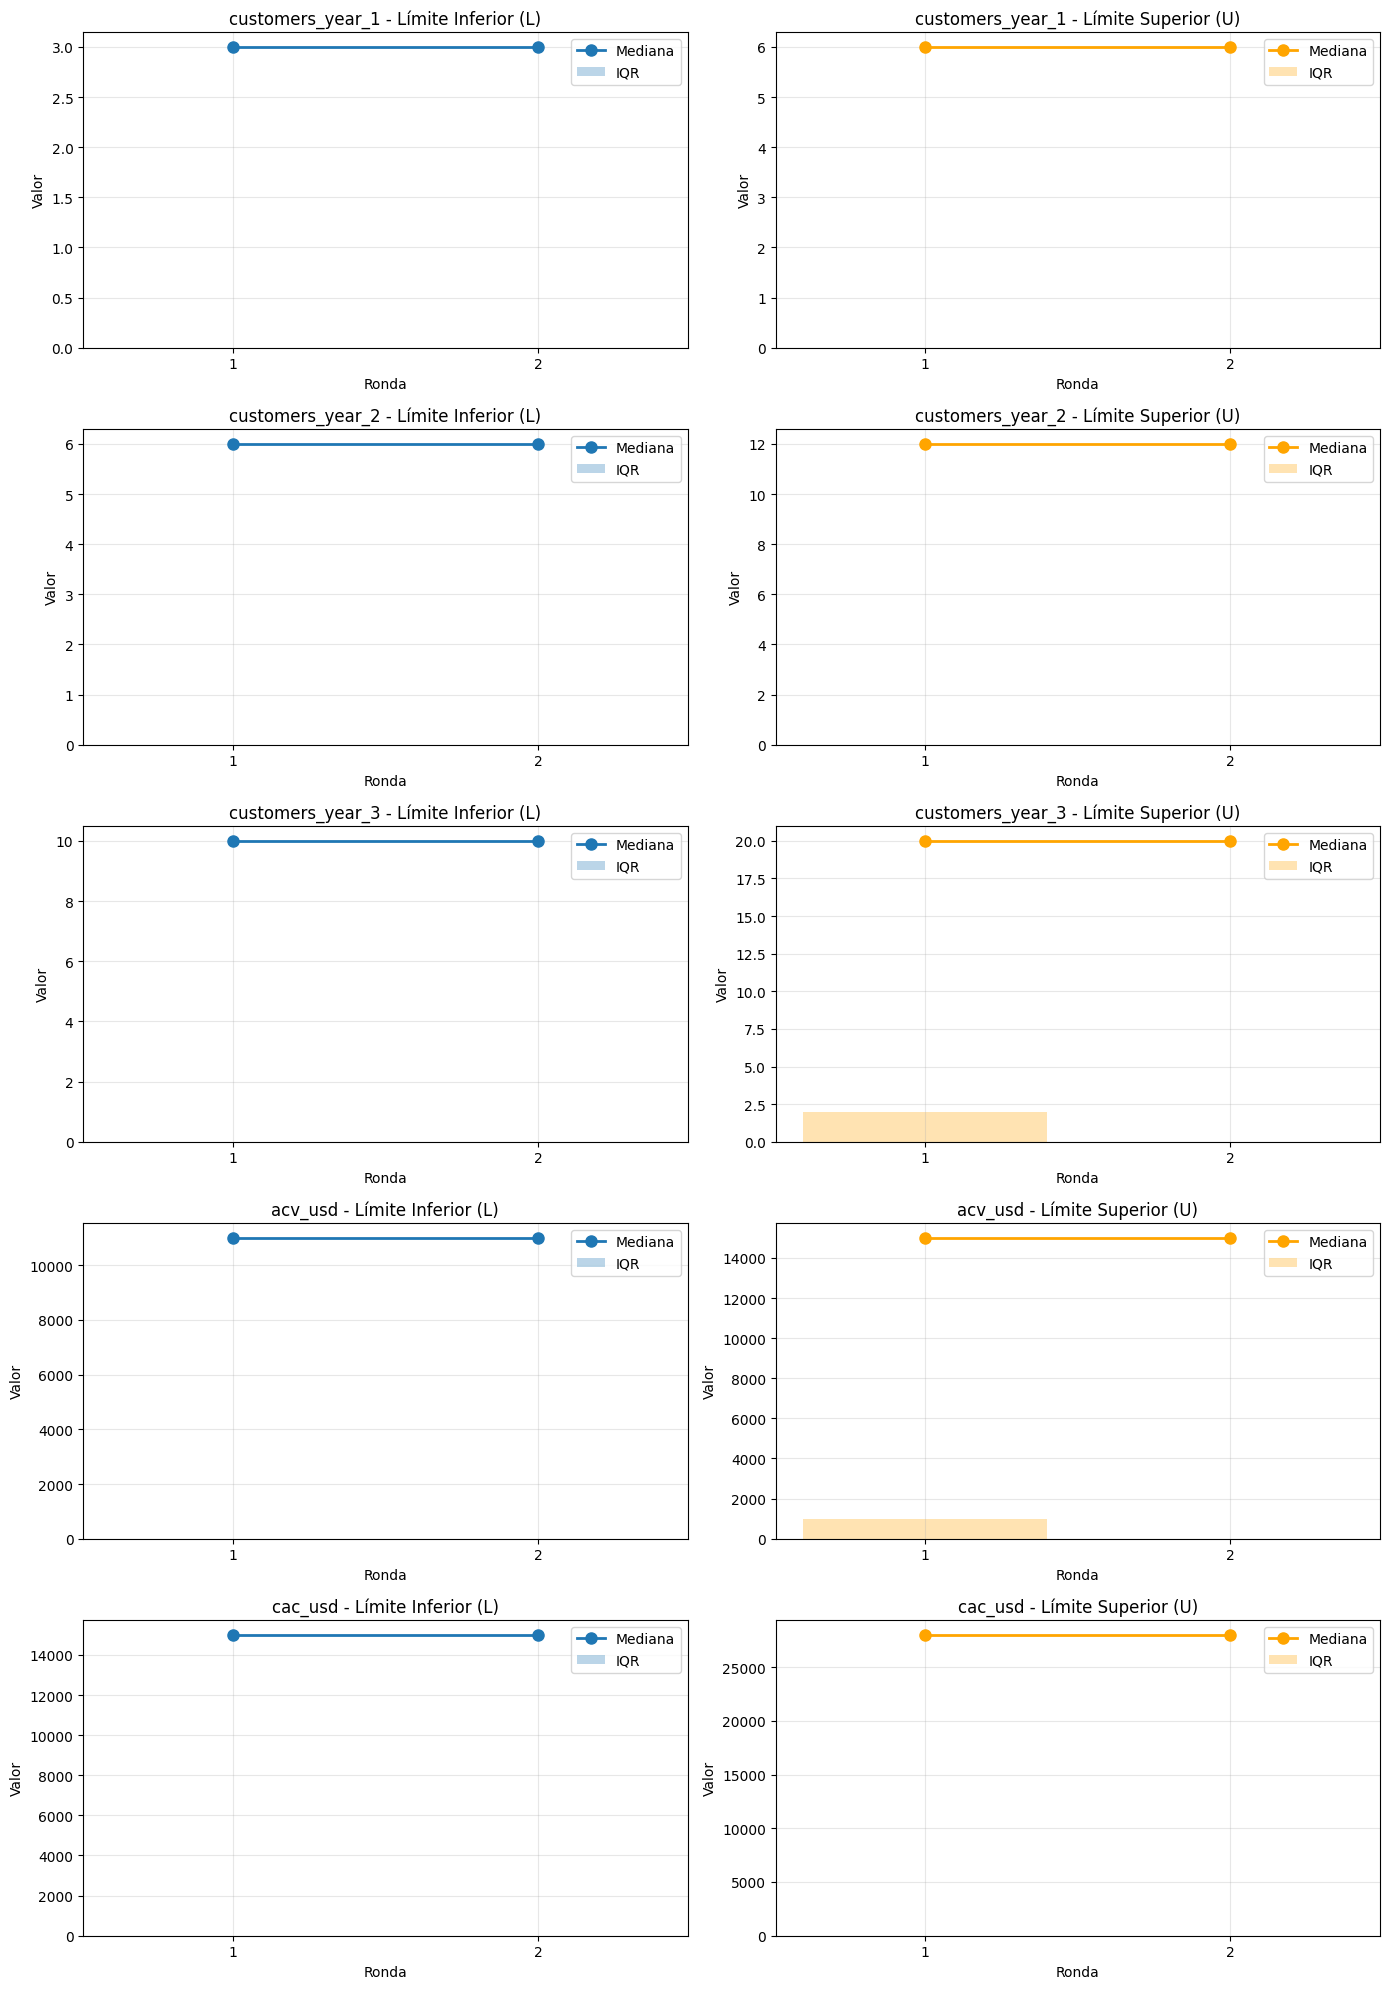

In [36]:
import matplotlib.pyplot as plt

def plot_convergencia(df_all: pd.DataFrame, scenario: str = "neutral", variables: list = None):
    """
    Grafica la evolución de las medianas e IQR por variable a través de las rondas.
    """
    d = df_all[df_all["scenario"] == scenario].copy()
    
    if variables is None:
        variables = sorted(d["variable"].unique())
    
    n_vars = len(variables)
    fig, axes = plt.subplots(n_vars, 2, figsize=(14, 4*n_vars))
    
    if n_vars == 1:
        axes = axes.reshape(1, -1)
    
    for idx, var in enumerate(variables):
        d_var = d[d["variable"] == var]
        
        # Datos por ronda
        rounds = sorted(d_var["round_id"].unique())
        l_medians = []
        l_iqrs = []
        u_medians = []
        u_iqrs = []
        
        for r in rounds:
            d_r = d_var[d_var["round_id"] == r]
            l_medians.append(d_r["L"].median())
            l_iqrs.append(d_r["L"].quantile(0.75) - d_r["L"].quantile(0.25))
            u_medians.append(d_r["U"].median())
            u_iqrs.append(d_r["U"].quantile(0.75) - d_r["U"].quantile(0.25))
        
        # Plot L
        ax_l = axes[idx, 0]
        ax_l.plot(rounds, l_medians, marker='o', linewidth=2, markersize=8, label='Mediana')
        ax_l.bar(rounds, l_iqrs, alpha=0.3, label='IQR')
        ax_l.set_title(f"{var} - Límite Inferior (L)")
        ax_l.set_xlabel("Ronda")
        ax_l.set_ylabel("Valor")
        ax_l.legend()
        ax_l.grid(True, alpha=0.3)
        ax_l.set_xticks(rounds)
        
        # Plot U
        ax_u = axes[idx, 1]
        ax_u.plot(rounds, u_medians, marker='o', linewidth=2, markersize=8, label='Mediana', color='orange')
        ax_u.bar(rounds, u_iqrs, alpha=0.3, label='IQR', color='orange')
        ax_u.set_title(f"{var} - Límite Superior (U)")
        ax_u.set_xlabel("Ronda")
        ax_u.set_ylabel("Valor")
        ax_u.legend()
        ax_u.grid(True, alpha=0.3)
        ax_u.set_xticks(rounds)
    
    plt.tight_layout()
    plt.show()

# Graficar las variables principales
main_vars = ["customers_year_1", "customers_year_2", "customers_year_3", "acv_usd", "cac_usd"]
plot_convergencia(df_round, scenario="neutral", variables=main_vars)

In [37]:
df_round

,round_id,role,scenario,variable,L,U
0,1,CEO y Co-fundador/a de una Startup Latinoameri...,pessimistic,customers_year_1,1.0,3.0
1,1,CEO y Co-fundador/a de una Startup Latinoameri...,pessimistic,customers_year_2,2.0,5.0
2,1,CEO y Co-fundador/a de una Startup Latinoameri...,pessimistic,customers_year_3,3.0,7.0
3,1,CEO y Co-fundador/a de una Startup Latinoameri...,pessimistic,acv_usd,9000.0,12000.0
4,1,CEO y Co-fundador/a de una Startup Latinoameri...,pessimistic,cac_usd,18000.0,35000.0
...,...,...,...,...,...,...
205,2,Investigador académico en Inteligencia Artific...,optimistic,customers_year_3,20.0,35.0
206,2,Investigador académico en Inteligencia Artific...,optimistic,acv_usd,14000.0,22000.0
207,2,Investigador académico en Inteligencia Artific...,optimistic,cac_usd,12000.0,22000.0
208,2,Investigador académico en Inteligencia Artific...,optimistic,annual_churn_pct,3.0,8.0
